# Gehl Activity Heatmaps — KDE Density

**Library:** [`sitex`](../sitex) · **Original, fully-documented version:** [`04-VIZ-POIsHeatmaps.ipynb`](../documentations/04-VIZ-POIsHeatmaps.ipynb)

*Where* each Gehl activity concentrates, as a KDE density glow over building
footprints — the density counterpart to the plain categorical point map
(`04-VIZ-Gehl_Webmap.ipynb`).

**Rendering avoids `scipy.stats.gaussian_kde` and `seaborn.kdeplot` entirely.** This
project's numpy/BLAS build crashes the interpreter outright on *any*
matrix-multiplication-backed operation — reproduced with a bare `numpy.cov()` and even
a bare `a @ a.T`, with no scipy/seaborn/matplotlib involved at all (`gaussian_kde`
computes its bandwidth via `np.cov()` internally). `sitex.viz.heatmaps.compute_kde_density`
hand-rolls the same Gaussian KDE from elementwise operations only (`np.std`, broadcasting,
`np.exp`) — confirmed safe — and rendering goes through `sitex.core.raster_viz` (PIL),
not matplotlib.

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[viz] @ git+https://github.com/ArchiColab/sitex.git"

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[viz] @ git+https://github.com/ArchiColab/sitex.git"

    # Input data (read-only) — downloaded fresh each session from the workshop's GitHub release
    DATA_RELEASE_URL = "https://github.com/ArchiColab/sitex/releases/download/workshop-data-v1/Colab_Outputs.zip"
    DATA_DIR = Path("/content/Colab_Outputs")
    if not DATA_DIR.exists():
        import urllib.request, zipfile
        zip_path = Path("/content/Colab_Outputs.zip")
        urllib.request.urlretrieve(DATA_RELEASE_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)

    # Your own results — saved to your own Google Drive so they persist across sessions
    from google.colab import drive
    drive.mount("/content/gdrive")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import geopandas as gpd
from IPython.display import Image, display

from sitex.core.config import CityConfig
from sitex.core.raster_viz import hstack_images, save_array_png
from sitex.viz import heatmaps as hm

## 1. Configuration & inputs

In [2]:
city = CityConfig(
    place_name="Phường Pleiku, Gia Lai, Vietnam",
    local_lat=13.9833,
    local_lon=108.0000,
    slug="phường_pleiku",
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)
CITY_KEY = "pleiku"
GRID_SIZE = 400

pois = gpd.read_file(city.data_dir / "overture" / f"pois_classified_{CITY_KEY}.gpkg")
print(f"{len(pois):,} classified POIs loaded — CRS: {pois.crs}")

buildings = gpd.read_file(city.data_dir / "overture" / f"{city.slug}_buildings.gpkg").to_crs(pois.crs)
print(f"{len(buildings):,} building footprints loaded — CRS: {buildings.crs}")

minx, miny, maxx, maxy = pois.total_bounds
pad_x, pad_y = (maxx - minx) * 0.07, (maxy - miny) * 0.07
XLIM = (minx - pad_x, maxx + pad_x)
YLIM = (miny - pad_y, maxy + pad_y)
buildings_clip = buildings.cx[XLIM[0]:XLIM[1], YLIM[0]:YLIM[1]]

3,091 classified POIs loaded — CRS: EPSG:32649
21,287 building footprints loaded — CRS: EPSG:32649


## 2. Gehl activity heatmaps — Necessary, Optional, Social

A POI can qualify for more than one activity (e.g. a cafe is often both Optional and
Social), so the three heatmaps below are independent boolean masks, not one exclusive
category — a place can and does show up in more than one panel.

Necessary (n=1,380)
Optional (n=594)
Social (n=2,047)
Saved -> ..\..\outputs\gehl_activities_heatmap_pleiku.png


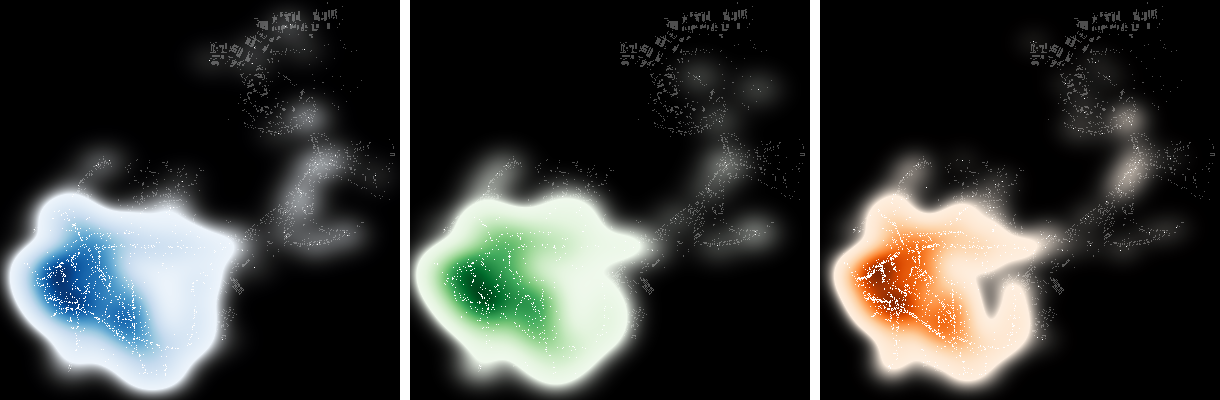

In [3]:
GEHL_EVENTS = {"Necessary": ("is_necessary", "Blues"), "Optional": ("is_optional", "Greens"), "Social": ("is_social", "Oranges")}

panels = []
for activity, (flag_col, cmap) in GEHL_EVENTS.items():
    subset = pois[pois[flag_col]]
    rgba = hm.render_gehl_heatmap(subset, buildings_clip, XLIM, YLIM, cmap, grid_size=GRID_SIZE)
    panels.append(save_array_png(rgba, city.output_dir / f"_gehl_{flag_col}.png"))
    print(f"{activity} (n={len(subset):,})")

gehl_path = city.output_dir / f"gehl_activities_heatmap_{CITY_KEY}.png"
hstack_images(panels, gehl_path)
print(f"Saved -> {gehl_path}")
display(Image(str(gehl_path)))

## 3. Third Space heatmap

`is_thirdspace` is a first-pass rule (functional-group based) — treat this as a draft
worth sanity-checking against the map, not a finished result.

Third Space (candidate), n=2,600
Saved -> ..\..\outputs\thirdspace_heatmap_pleiku.png


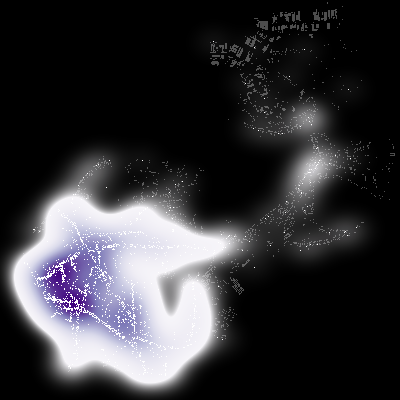

In [4]:
thirdspace = pois[pois["is_thirdspace"]]
rgba = hm.render_gehl_heatmap(thirdspace, buildings_clip, XLIM, YLIM, "Purples", grid_size=GRID_SIZE)

thirdspace_path = city.output_dir / f"thirdspace_heatmap_{CITY_KEY}.png"
save_array_png(rgba, thirdspace_path)
print(f"Third Space (candidate), n={len(thirdspace):,}")
print(f"Saved -> {thirdspace_path}")
display(Image(str(thirdspace_path)))

---
## Doing this in QGIS (studio layout session)

Students working in QGIS instead of this notebook can reproduce the same heatmaps with
the built-in **Heatmap (Kernel Density Estimation)** tool — no Python needed.

1. **Load the POIs layer** — `data/overture/pois_classified_pleiku.gpkg` (metric UTM
   CRS) or the `.geojson` for a WGS84 project.
2. **Filter to one Gehl activity at a time** — `Properties → Source → Query Builder`,
   e.g. `"is_necessary" = 1` (swap in `is_optional`, `is_social`, or `is_thirdspace`).
3. **Run the heatmap tool** — `Processing Toolbox → "Heatmap (Kernel Density Estimation)"`;
   radius ~150–250 m (comparable to this notebook's KDE bandwidth), pixel size ~10 m.
4. **Style it** — `Symbology → Singleband pseudocolor`, a colour ramp matching this
   notebook (Blues/Greens/Oranges/Purples), `Stretch to MinMax`.
5. **Repeat per activity**, keeping each output as its own layer so they toggle
   independently.